In [ ]:
!pip install GEOparse xgboost shap gseapy seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.6/664.6 kB 26.3 MB/s eta 0:00:00


In [ ]:
import GEOparse
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import warnings
warnings.filterwarnings("ignore")

In [ ]:
gse = GEOparse.get_GEO(
    geo="GSE45827",
    destdir="./"
)

print(gse)

26-Jun-2026 02:31:12 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
26-Jun-2026 02:31:12 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to ./GSE45827_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to ./GSE45827_family.soft.gz
100%|██████████| 40.1M/40.1M [00:02<00:00, 18.1MB/s]
26-Jun-2026 02:31:15 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
26-Jun-2026 02:31:15 DEBUG downloader - Moving /tmp/tmp61466q6f to /content/GSE45827_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp61466q6f to /content/GSE45827_family.soft.gz
26-Jun-2026 02:31:15 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45

<SERIES: GSE45827 - 155 SAMPLES, 1 d(s)>


In [ ]:
#expression-matrix
X = gse.pivot_samples("VALUE").T

print(X.shape)

(155, 29873)


In [ ]:
#metadata
meta = gse.phenotype_data

print(meta.columns)

meta.head()

Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.diagnosis',
       'characteristics_ch1.1.tumor subtype', 'characteristics_ch1.2.batch',
       'characteristics_ch1.3.hybridation', 'molecule_ch1',
       'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1',
       'hyb_protocol', 'scan_protocol', 'data_processing', 'platform_id',
       'contact_name', 'contact_email', 'contact_phone', 'contact_fax',
       'contact_laboratory', 'contact_department', 'contact_institute',
       'contact_address', 'contact_city', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'series_id', 'data_row_count',
       'characteristics_ch1.0.cell line', 'characteristics_ch1.1.cell origin'],
      dtype='object')


,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,contact_institute,contact_address,contact_city,contact_zip/postal_code,contact_country,supplementary_file,series_id,data_row_count,characteristics_ch1.0.cell line,characteristics_ch1.1.cell origin
GSM1116084,Basal Sample1 rep1,GSM1116084,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Basal Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116085,Basal Sample2 rep1-2,GSM1116085,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Basal Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116086,Her2 Sample3 rep1,GSM1116086,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Her2 Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116087,Basal Sample4 rep1-2,GSM1116087,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Basal Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN
GSM1116088,Her2 Sample5 rep1-2,GSM1116088,Public on Mar 24 2016,Apr 05 2013,Mar 24 2016,RNA,1,Human Her2 Tumor Sample,Homo sapiens,9606,...,Institut Curie,26 rue d'Ulm,PARIS,75248,France,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1116...,GSE45827,29873,NaN,NaN


In [ ]:
#extract subtypes
for col in meta.columns:
    if "characteristics" in col.lower():
        print(col)
        print(meta[col].unique()[:20])
        print("="*50)

characteristics_ch1.0.diagnosis
['Breast cancer' nan 'None (normal)']
characteristics_ch1.1.tumor subtype
['Basal' 'Her2' nan 'N/A' 'Luminal A' 'Luminal B']
characteristics_ch1.2.batch
['8' '9' '10' '2' '5' '1' '4' '3']
characteristics_ch1.3.hybridation
['-1' '2' '1' '3']
characteristics_ch1.0.cell line
[nan 'BT20' 'HCC70' 'HCC1143' 'HCC1187' 'HCC1937' 'MDA-MB-468' 'HCC38'
 'MDA-MB-231' 'MDA-MB-436' 'MDA-MB-157' 'BT-549' 'Hs 578T' 'MCF-12A'
 '184B5']
characteristics_ch1.1.cell origin
[nan 'Breast carcinoma' 'Breast mammary gland']


In [ ]:
#only tumor
subtype_col = "characteristics_ch1.1.tumor subtype"

subtypes = meta[subtype_col].astype(str)

mask = subtypes.isin([
    "Basal",
    "Her2",
    "Luminal A",
    "Luminal B"
])

X = X.loc[mask]
y = subtypes[mask]

print(y.value_counts())
print("\nTotal samples:", len(y))

characteristics_ch1.1.tumor subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Name: count, dtype: int64

Total samples: 130


In [ ]:
#encode labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Basal' 'Her2' 'Luminal A' 'Luminal B']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
#feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=300
)
X_train = selector.fit_transform(
    X_train,
    y_train
)

X_test = selector.transform(X_test)

print(X_train.shape)

(104, 300)


In [ ]:
#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#model
model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,

    n_estimators=500,

    max_depth=5,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.5,

    reg_lambda=1.0,

    random_state=42,

    eval_metric="mlogloss"
)
model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=4, ...)

In [ ]:
#prediction
y_pred = model.predict(X_test)

acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy = {acc:.4f}"
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

Accuracy = 1.0000
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         8
        Her2       1.00      1.00      1.00         6
   Luminal A       1.00      1.00      1.00         6
   Luminal B       1.00      1.00      1.00         6

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



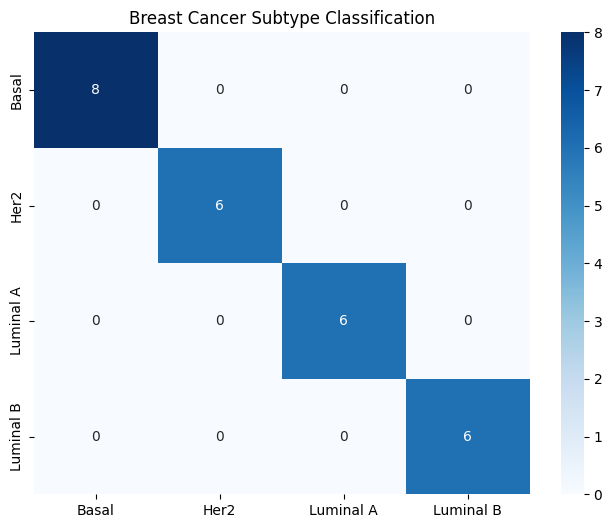

In [ ]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "Breast Cancer Subtype Classification"
)
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
#5fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#CORRECT — use Pipeline so selector fits only on training folds
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("selector",  SelectKBest(mutual_info_classif, k=300)),
    ("scaler",    StandardScaler()),
    ("model",     XGBClassifier(eval_metric="mlogloss", random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline, X, y_encoded,
    cv=cv, scoring="accuracy"
)

print("CV Accuracy:", scores)
print(f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")

CV Accuracy: [0.84615385 0.92307692 0.96153846 0.92307692 1.        ]
Mean: 0.9308 ± 0.0510


In [ ]:
#top biomarker
feature_idx = selector.get_support()

selected_genes = X.columns[feature_idx]

importance = model.feature_importances_

top_genes = pd.DataFrame({
    "Gene": selected_genes,
    "Importance": importance
})

top_genes = top_genes.sort_values(
    "Importance",
    ascending=False
)

top_genes.head(30)

,Gene,Importance
48,203554_x_at,0.082536
286,236641_at,0.041368
189,219918_s_at,0.040707
76,205046_at,0.032587
169,218211_s_at,0.029525
111,210691_s_at,0.028914
271,232322_x_at,0.023775
43,203358_s_at,0.022421
115,210930_s_at,0.021696
37,202908_at,0.021427


In [ ]:
#save biomarkers
top_genes.to_csv(
    "top_biomarkers.csv",
    index=False
)

In [ ]:
#shap explainability
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_test
)

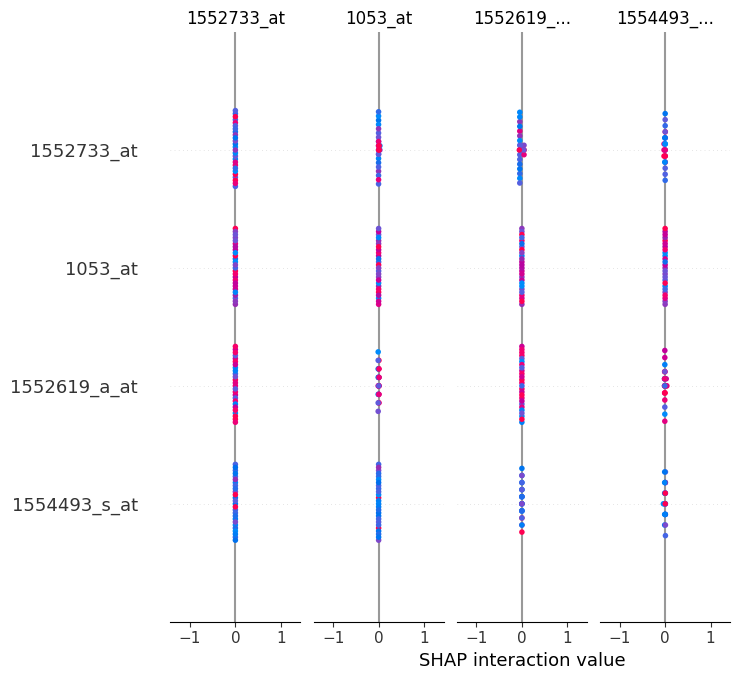

In [ ]:
#shap summary
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=selected_genes
)

In [ ]:
import gseapy as gp

gene_list = (
    top_genes["Gene"]
    .head(50)
    .tolist()
)




print(gene_list[:10])


['203554_x_at', '236641_at', '219918_s_at', '205046_at', '218211_s_at', '210691_s_at', '232322_x_at', '203358_s_at', '210930_s_at', '202908_at']


In [ ]:
!pip install mygene
import mygene

mg = mygene.MyGeneInfo()

# Query probe IDs using "reporter" scope (handles Affymetrix IDs)
results = mg.querymany(
    gene_list,
    scopes="reporter",       # tells mygene these are microarray probe IDs
    fields="symbol",
    species="human"
)

# Extract symbols, drop unmapped probes
gene_symbols = []
for r in results:
    if "symbol" in r and r["symbol"] not in gene_symbols:
        gene_symbols.append(r["symbol"])

print(f"Probes submitted: {len(gene_list)}")
print(f"Symbols mapped:   {len(gene_symbols)}")
print(gene_symbols[:10])
print(gene_symbols)


INFO:biothings.client:querying 1-50 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Probes submitted: 50
Symbols mapped:   46
['PTTG1', 'KIF14', 'ASPM', 'CENPE', 'MLPH', 'CACYBP', 'STARD10', 'EZH2', 'ERBB2', 'WFS1']
['PTTG1', 'KIF14', 'ASPM', 'CENPE', 'MLPH', 'CACYBP', 'STARD10', 'EZH2', 'ERBB2', 'WFS1', 'AURKA', 'CENPA', 'SLC35F6', 'CDCA3', 'CCNB2', 'MND1', 'UBE2T', 'NME3', 'SUV39H2', 'GRB7', 'AGR2', 'CDCA5', 'CEP126', 'MYBL2', 'CDC6', 'SPDEF', 'SPAG5', 'BUB1', 'IL6ST', 'ESR1', 'GATA3', 'SMIM13', 'AURKB', 'EME2', 'GABRP', 'BTG3', 'CFAP69', 'CMC2', 'GPN1', 'FOXM1', 'ZNF740', 'ABAT', 'LRRC37A2', 'LRRC37A4P', 'SRSF5', 'CA12']


In [ ]:
enr = gp.enrichr(
    gene_list=gene_symbols,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2023"],
    organism="human",
    outdir=None,
    cutoff=0.5
)

df = enr.results.sort_values("Adjusted P-value")['PTTG1', 'KIF14', 'ASPM', 'CENPE', 'MLPH', 'CACYBP', 'STARD10', 'EZH2', 'ERBB2', 'WFS1']
['PTTG1', 'KIF14', 'ASPM', 'CENPE', 'MLPH', 'CACYBP', 'STARD10', 'EZH2', 'ERBB2', 'WFS1', 'AURKA', 'CENPA', 'SLC35F6', 'CDCA3', 'CCNB2', 'MND1', 'UBE2T', 'NME3', 'SUV39H2', 'GRB7', 'AGR2', 'CDCA5', 'CEP126', 'MYBL2', 'CDC6', 'SPDEF', 'SPAG5', 'BUB1', 'IL6ST', 'ESR1', 'GATA3', 'SMIM13', 'AURKB', 'EME2', 'GABRP', 'BTG3', 'CFAP69', 'CMC2', 'GPN1', 'FOXM1', 'ZNF740', 'ABAT', 'LRRC37A2', 'LRRC37A4P', 'SRSF5', 'CA12']
print(df[df["Adjusted P-value"] < 0.05][["Term", "Overlap", "Adjusted P-value"]].head(15))

                                                 Term Overlap  \
0             Progesterone-mediated oocyte maturation   5/100   
1                                          Cell cycle   5/124   
2                                      Oocyte meiosis   5/129   
88  Positive Regulation Of Cell Cycle Process (GO:...   5/118   
3                              Fanconi anemia pathway    3/54   
89             Regulation Of Cytokinesis (GO:0032465)    4/80   
90         Positive Regulation Of Growth (GO:0045927)    4/81   
91  Phosphatidylinositol 3-Kinase Signaling (GO:00...    3/32   
92      Cell Cycle G2/M Phase Transition (GO:0044839)    3/40   
93      Regulation Of Cell Cycle Process (GO:0010564)   4/130   
94  Regulation Of Cyclin-Dependent Protein Kinase ...    3/53   
95  Positive Regulation Of Transferase Activity (G...   4/143   
96  Phosphatidylinositol-Mediated Signaling (GO:00...    3/62   
97           Protein Autophosphorylation (GO:0046777)   4/162   
98                       

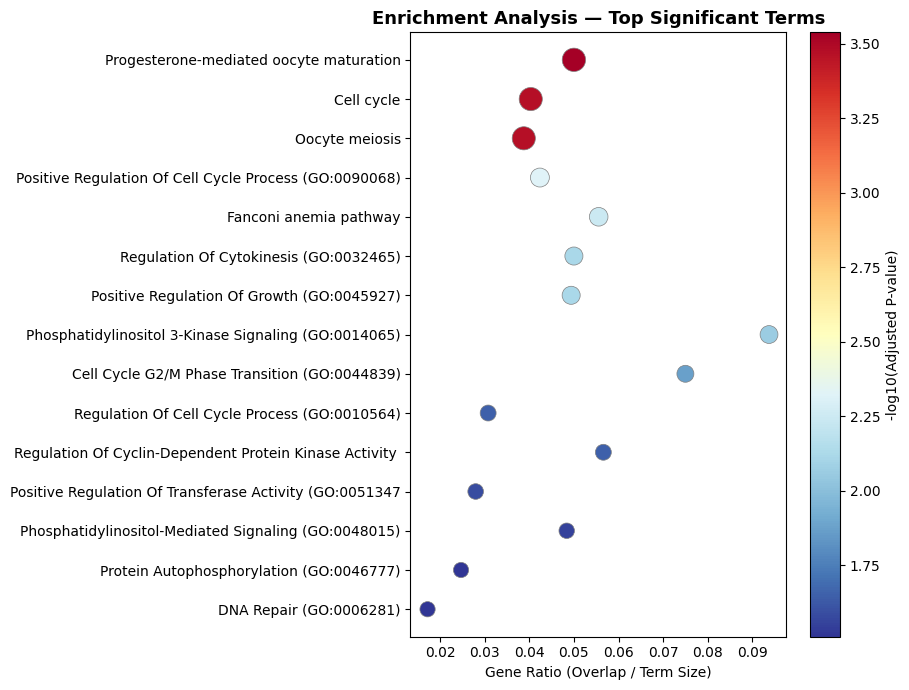

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_sig = enr.results[enr.results["Adjusted P-value"] < 0.05].copy()

# Parse overlap ratio for dot size
df_sig["overlap_ratio"] = df_sig["Overlap"].apply(
    lambda x: int(x.split("/")[0]) / int(x.split("/")[1])
)
df_sig["-log10(FDR)"] = -np.log10(df_sig["Adjusted P-value"])

# Shorten long term names
df_sig["Term_short"] = df_sig["Term"].str.slice(0, 55)

# Sort and take top 15
df_plot = df_sig.sort_values("Adjusted P-value").head(15)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df_plot["overlap_ratio"],
    df_plot["Term_short"],
    s=df_plot["-log10(FDR)"] * 80,
    c=df_plot["-log10(FDR)"],
    cmap="RdYlBu_r",
    edgecolors="grey",
    linewidths=0.5
)

plt.colorbar(scatter, ax=ax, label="-log10(Adjusted P-value)")
ax.set_xlabel("Gene Ratio (Overlap / Term Size)")
ax.set_title("Enrichment Analysis — Top Significant Terms", fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("enrichment_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()

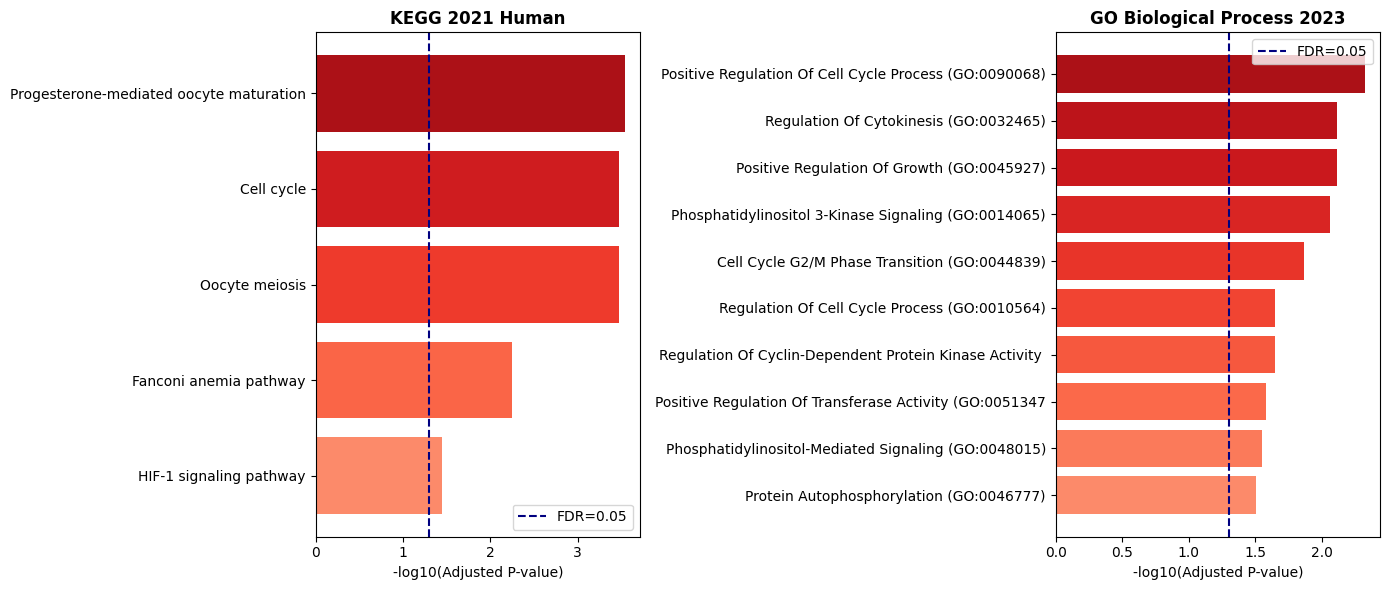

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gs in zip(axes, ["KEGG_2021_Human", "GO_Biological_Process_2023"]):
    sub = df_sig[df_sig["Gene_set"] == gs].sort_values("Adjusted P-value").head(10)
    bars = ax.barh(
        sub["Term_short"],
        -np.log10(sub["Adjusted P-value"]),
        color=plt.cm.Reds(np.linspace(0.4, 0.85, len(sub)))[::-1]
    )
    ax.axvline(x=-np.log10(0.05), color="navy", linestyle="--", label="FDR=0.05")
    ax.set_xlabel("-log10(Adjusted P-value)")
    ax.set_title(gs.replace("_", " "), fontweight="bold")
    ax.invert_yaxis()
    ax.legend()

plt.tight_layout()
plt.savefig("enrichment_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

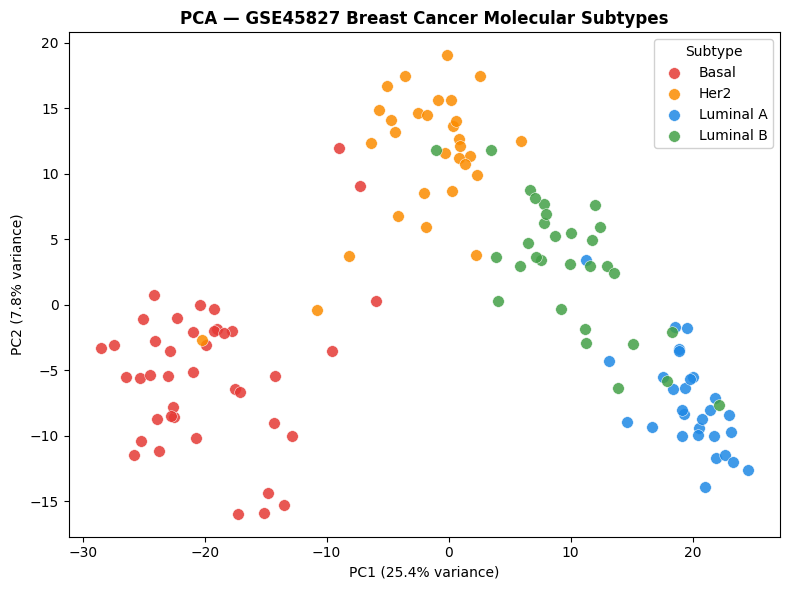

In [ ]:
#pca plot
from sklearn.decomposition import PCA

# Use top 1000 most variable genes on full dataset
var_genes_idx = X.var(axis=0).nlargest(1000).index
X_pca_input = X[var_genes_idx]

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(StandardScaler().fit_transform(X_pca_input))

pc_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pc_df["Subtype"] = y.values

palette = {
    "Basal":     "#E53935",
    "Her2":      "#FB8C00",
    "Luminal A": "#1E88E5",
    "Luminal B": "#43A047"
}

plt.figure(figsize=(8, 6))
for subtype, grp in pc_df.groupby("Subtype"):
    plt.scatter(grp["PC1"], grp["PC2"],
                label=subtype, s=70, alpha=0.85,
                color=palette[subtype], edgecolors="white", linewidths=0.4)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — GSE45827 Breast Cancer Molecular Subtypes", fontweight="bold")
plt.legend(title="Subtype", framealpha=0.9)
plt.tight_layout()
plt.savefig("PCA_subtypes.png", dpi=150)
plt.show()

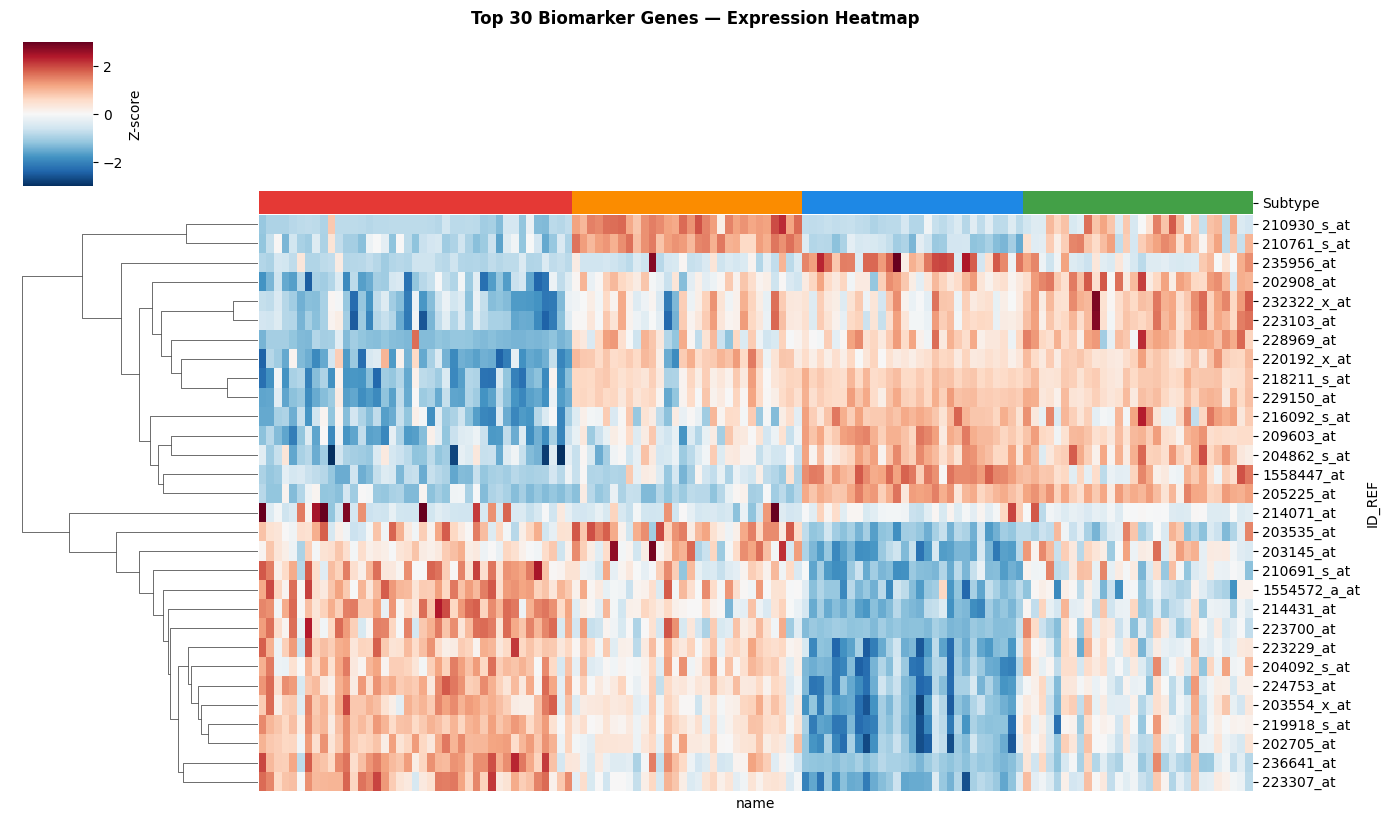

In [ ]:
#heat-map
# Get top 30 probe IDs by importance
top30_probes = top_genes["Gene"].head(30).tolist()

# Subset expression and add subtype labels
heatmap_df = X[top30_probes].copy()
heatmap_df["Subtype"] = y.values
heatmap_df = heatmap_df.sort_values("Subtype")

# Z-score normalize each gene
from scipy.stats import zscore
expr_matrix = heatmap_df[top30_probes].apply(zscore)

# Subtype color bar
subtype_colors = heatmap_df["Subtype"].map(palette)

sns.clustermap(
    expr_matrix.T,
    col_colors=subtype_colors,
    cmap="RdBu_r",
    figsize=(14, 8),
    col_cluster=False,    # keep subtypes grouped
    row_cluster=True,
    center=0,
    vmin=-3, vmax=3,
    yticklabels=True,
    xticklabels=False,
    cbar_kws={"label": "Z-score"}
)
plt.suptitle("Top 30 Biomarker Genes — Expression Heatmap", y=1.02, fontweight="bold")
plt.savefig("biomarker_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

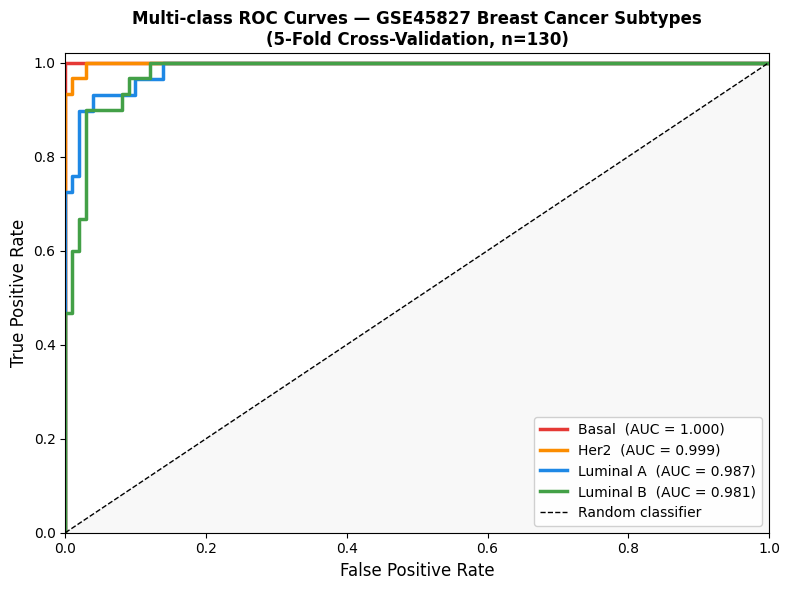

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold

# Get out-of-fold probability predictions (honest evaluation)
pipeline = Pipeline([
    ("selector", SelectKBest(mutual_info_classif, k=300)),
    ("scaler",   StandardScaler()),
    ("model",    XGBClassifier(eval_metric="mlogloss", random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# This gives probabilities for ALL 130 samples without leakage
y_prob_cv = cross_val_predict(
    pipeline, X, y_encoded,
    cv=cv,
    method="predict_proba"   # ← key: gets probabilities not labels
)

# Binarize labels for one-vs-rest ROC
y_bin = label_binarize(y_encoded, classes=[0, 1, 2, 3])

# ── Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors    = ["#E53935", "#FB8C00", "#1E88E5", "#43A047"]
subtypes  = encoder.classes_   # ['Basal', 'Her2', 'Luminal A', 'Luminal B']

for i, (cls, col) in enumerate(zip(subtypes, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_cv[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2.5,
            label=f"{cls}  (AUC = {roc_auc:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier")
ax.fill_between([0,1],[0,1], alpha=0.05, color="grey")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Multi-class ROC Curves — GSE45827 Breast Cancer Subtypes\n"
             "(5-Fold Cross-Validation, n=130)", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("ROC_CV_curves.png", dpi=150)
plt.show()

In [2]:
!pip install gseapy
import pandas as pd
import gseapy as gp

panel = pd.read_csv("reference_46gene_panel.csv")
gene_list = panel["gene_symbol"].dropna().unique().tolist()
print(f"Running Reactome enrichment on {len(gene_list)} genes.")

enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=["Reactome_2022"],
    organism="human",
    outdir=None,
)

results = enr.results
sig_results = results[results["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")

print(f"\n{len(sig_results)} significant Reactome pathways (FDR < 0.05):")
print(sig_results[["Term", "Overlap", "Adjusted P-value", "Genes"]].to_string(index=False))

sig_results.to_csv("reactome_enrichment_results.csv", index=False)
print("\nSaved: reactome_enrichment_results.csv")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.6/664.6 kB 35.0 MB/s eta 0:00:00
Running Reactome enrichment on 43 genes.

41 significant Reactome pathways (FDR < 0.05):
                                                                                                                  Term Overlap  Adjusted P-value                                                           Genes
                                                                                              Cell Cycle R-HSA-1640170  11/654          0.000019 CCNA2;CDC45;UBE2C;CDCA5;PSMD3;MCM10;MYBL2;MND1;CENPN;CDC6;AURKA
                                                                                       Cell Cycle, Mitotic R-HSA-69278  10/523          0.000019      CCNA2;CDC45;UBE2C;CDCA5;PSMD3;MCM10;MYBL2;CENPN;CDC6;AURKA
                                                                     Mitotic G1 Phase And G1/S Transition R-HSA-453279   6/147          0.000061                              CCNA2;CDC45;PSMD3;MCM10;MYBL2